# Extreme-Point Symmetric Mode Decomposition (ESMD)

Python reimplementation of **ESMD** (Wang & Li, *Adv. Adapt. Data Anal.*, 2013 / arXiv:1303.6540).

Unlike classical EMD (outer envelopes), ESMD sifts with **inner midpoint curves** through consecutive extrema:

| Variant | Interpolating curves |
| --- | --- |
| ESMD_I | all midpoints |
| **ESMD_II** (default) | odd / even midpoints |
| ESMD_III | residue classes mod 3 |

The residual with few extrema ($\le$ `extreme_num_r`, default 4) is the **Adaptive Global Mean (AGM)**. Optimal sifting count $K_0$ minimises

$$
\nu(K) = \frac{\sigma(Y-R)}{\sigma(Y)}.
$$

Instantaneous amplitude / frequency use the paper's **Direct Interpolation (DI)** scheme; energy $E(t)=\frac{1}{2}\sum_j A_j(t)^2$.

## 1. Imports

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import ESMD, esmd
from pysdkit._emd.esmd import make_esmd_example3

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.3})


## 2. Algorithm sketch

1. Locate extrema of the current residual $r(t)$.
2. Form midpoints of segments joining consecutive extrema; interpolate $p$ midpoint curves ($p=1,2,3$).
3. Mean curve $L^*(t)$ = average of those curves; sift $h \leftarrow h - L^*$ up to $K$ times (or until $\|L^*\|\le\varepsilon$).
4. Peel off an IMF; repeat until the residual has $\le$ `extreme_num_r` extrema → AGM $R$.
5. Scan $K\in[\texttt{min\_sift},\texttt{max\_sift}]$, pick $K_0=\arg\min \nu(K)$, then re-sift once with $K_0$.

## 3. Paper Example 3 — separable synthetic signal

$$
Y(t)=-\sin(8\pi t)+1.5\,e^{-0.2t}\sin\!\bigl(1.9\pi t+\pi/20\bigr)+(t-2)^2,
\qquad 0\le t\le 4.
$$

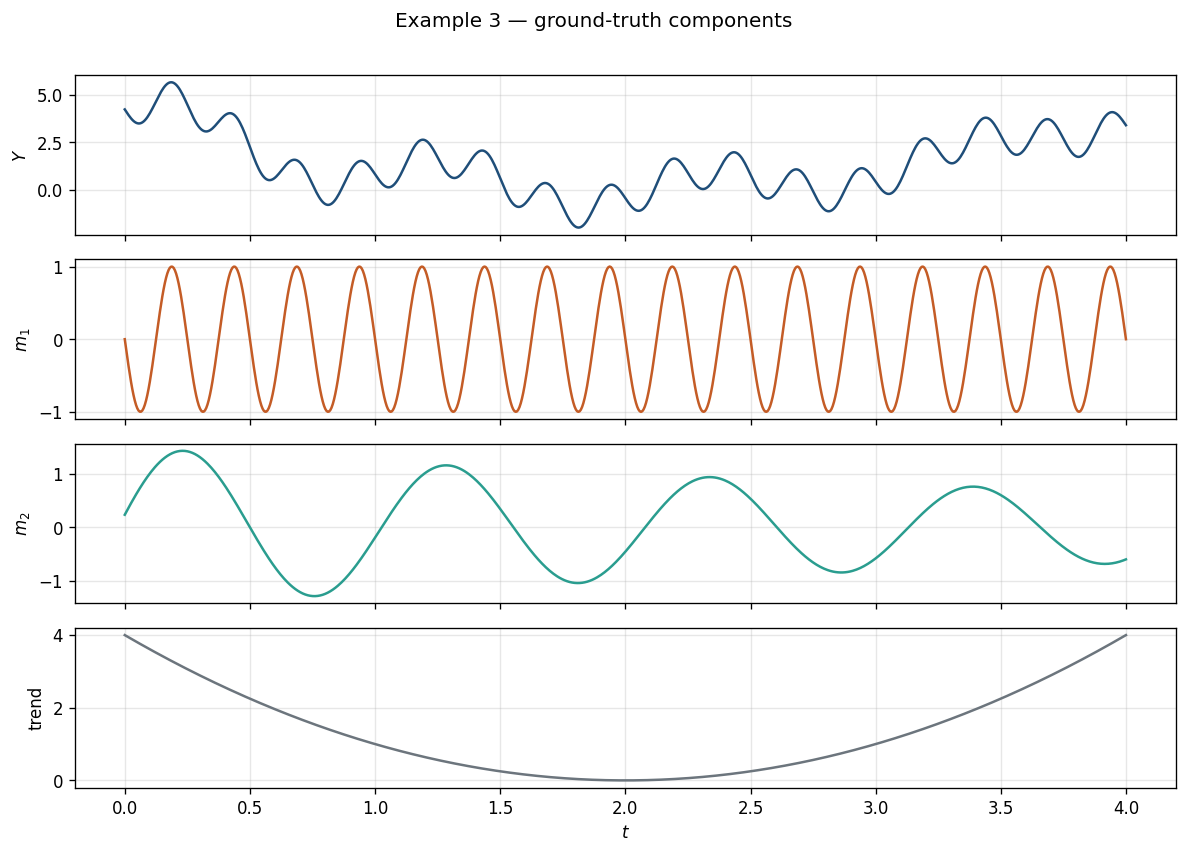

In [2]:
demo = make_esmd_example3(n=800)
t, y = demo["t"], demo["signal"]
dt = float(demo["dt"])

fig, axes = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, y, color="#1f4e79")
axes[0].set_ylabel("$Y$")
axes[1].plot(t, demo["mode1"], color="#c45c26")
axes[1].set_ylabel("$m_1$")
axes[2].plot(t, demo["mode2"], color="#2a9d8f")
axes[2].set_ylabel("$m_2$")
axes[3].plot(t, demo["trend"], color="#6c757d")
axes[3].set_ylabel("trend")
axes[3].set_xlabel("$t$")
fig.suptitle("Example 3 — ground-truth components", y=1.01)
plt.tight_layout()
plt.show()

opt K0 = 40
min nu  = 0.604411
IMFs+R shape = (3, 800)
reconstruction error = 8.882e-16


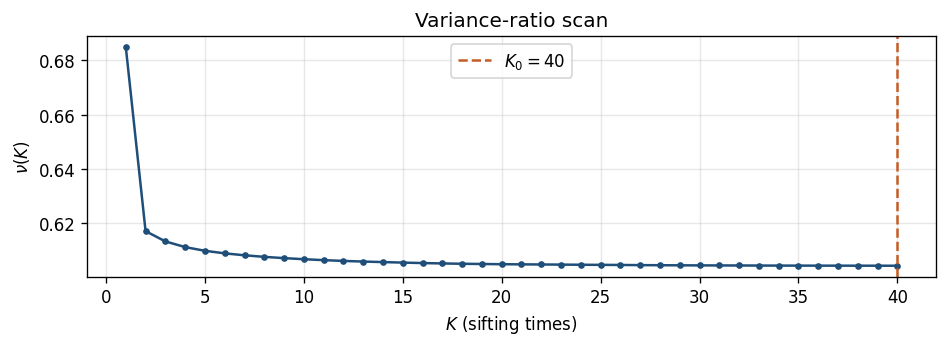

In [3]:
# ESMD_II with variance-ratio optimisation
decomp = ESMD(
    n_curves=2,
    min_sift=1,
    max_sift=40,
    extreme_num_r=4,
    optimize_sift=True,
    max_imfs=8,
)
imfs = decomp.fit_transform(y, dt=dt, compute_di=True)

print(f"opt K0 = {decomp.opt_sift_}")
print(f"min nu  = {np.min(decomp.variance_ratios_):.6f}")
print(f"IMFs+R shape = {imfs.shape}")
print(f"reconstruction error = {np.max(np.abs(y - imfs.sum(0))):.3e}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(decomp.sift_grid_, decomp.variance_ratios_, "o-", color="#1f4e79", ms=3)
ax.axvline(
    decomp.opt_sift_, color="#c45c26", ls="--", label=f"$K_0={decomp.opt_sift_}$"
)
ax.set_xlabel("$K$ (sifting times)")
ax.set_ylabel(r"$\nu(K)$")
ax.set_title("Variance-ratio scan")
ax.legend()
plt.tight_layout()
plt.show()

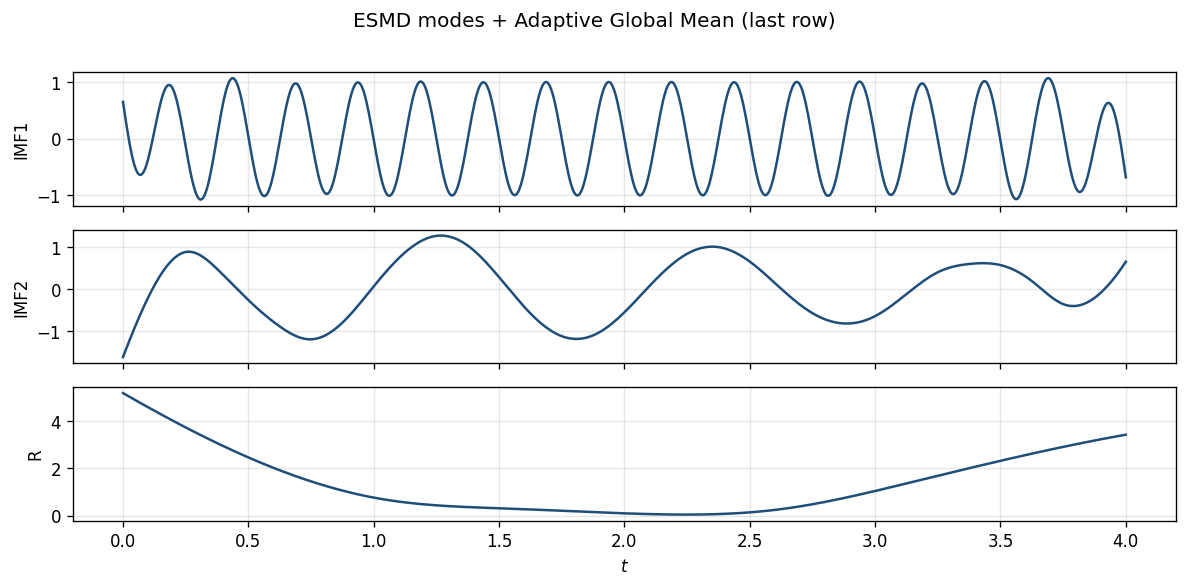

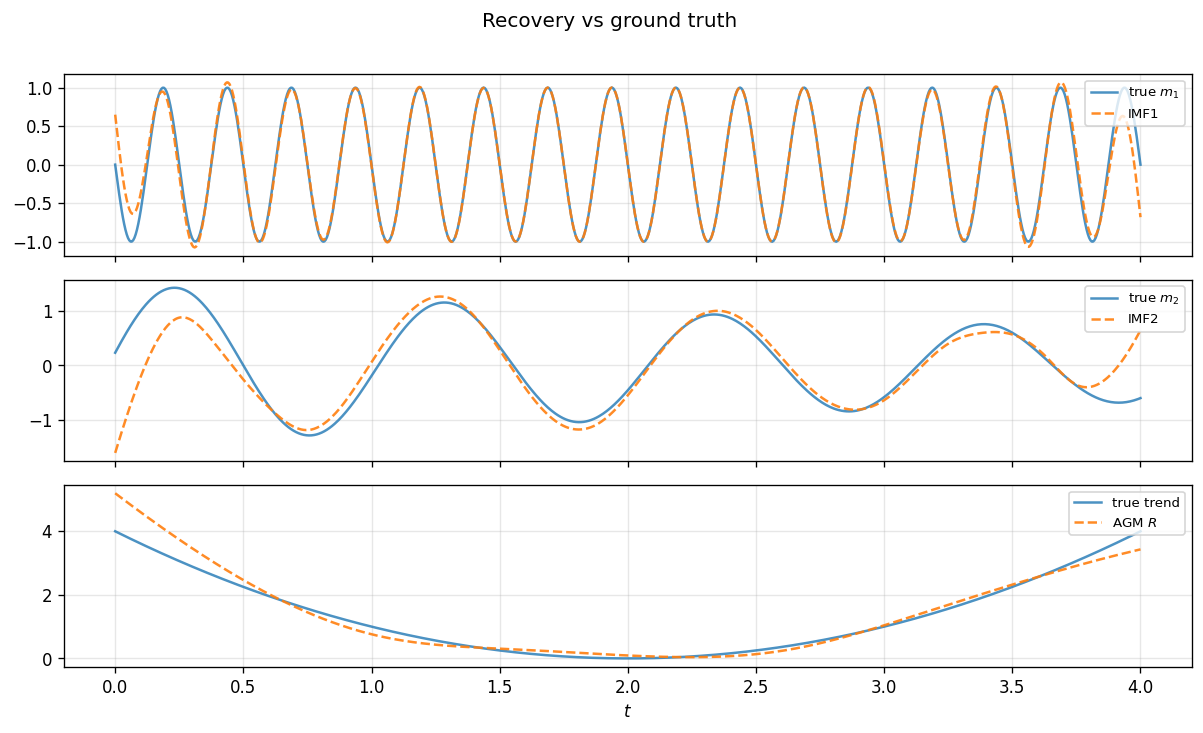

In [4]:
n_rows = imfs.shape[0]
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 1.6 * n_rows), sharex=True)
if n_rows == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(t, imfs[i], color="#1f4e79")
    ax.set_ylabel("R" if i == n_rows - 1 else f"IMF{i+1}")
axes[-1].set_xlabel("$t$")
fig.suptitle("ESMD modes + Adaptive Global Mean (last row)", y=1.01)
plt.tight_layout()
plt.show()

# Compare residual / first two modes with truth
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, demo["mode1"], label="true $m_1$", alpha=0.8)
axes[0].plot(t, imfs[0], "--", label="IMF1", alpha=0.9)
axes[1].plot(t, demo["mode2"], label="true $m_2$", alpha=0.8)
axes[1].plot(
    t, imfs[1] if imfs.shape[0] > 2 else imfs[0], "--", label="IMF2", alpha=0.9
)
axes[2].plot(t, demo["trend"], label="true trend", alpha=0.8)
axes[2].plot(t, imfs[-1], "--", label="AGM $R$", alpha=0.9)
for ax in axes:
    ax.legend(loc="upper right", fontsize=8)
axes[-1].set_xlabel("$t$")
fig.suptitle("Recovery vs ground truth", y=1.01)
plt.tight_layout()
plt.show()

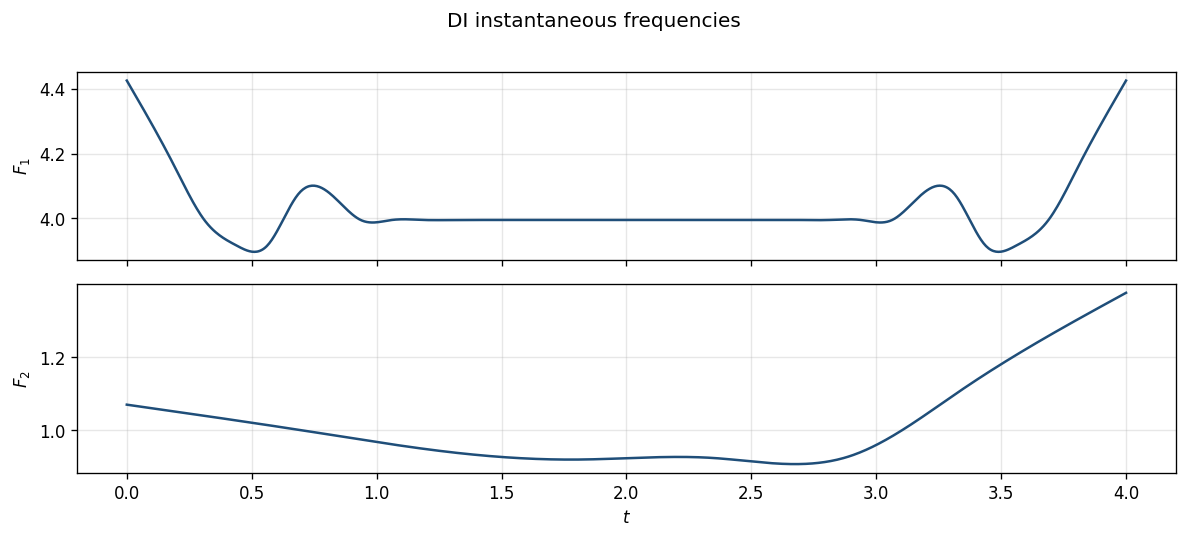

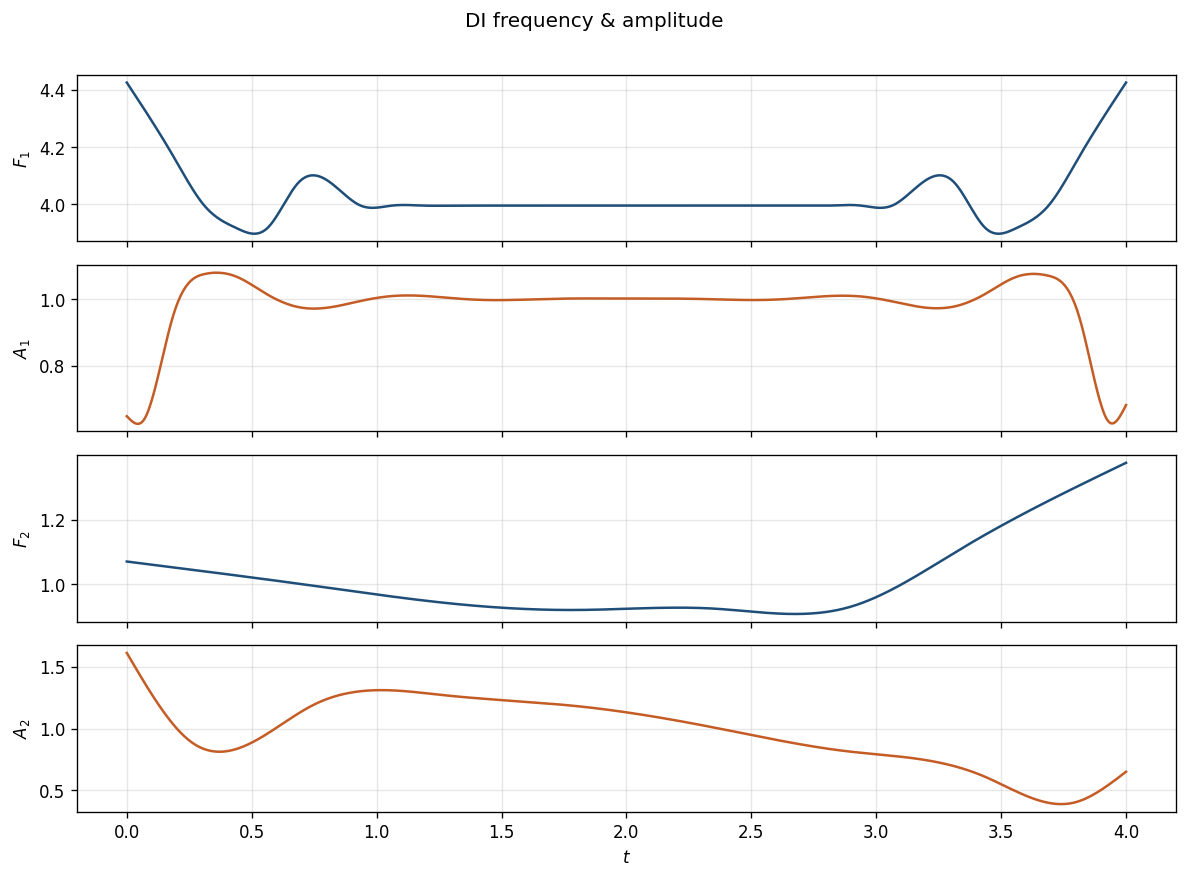

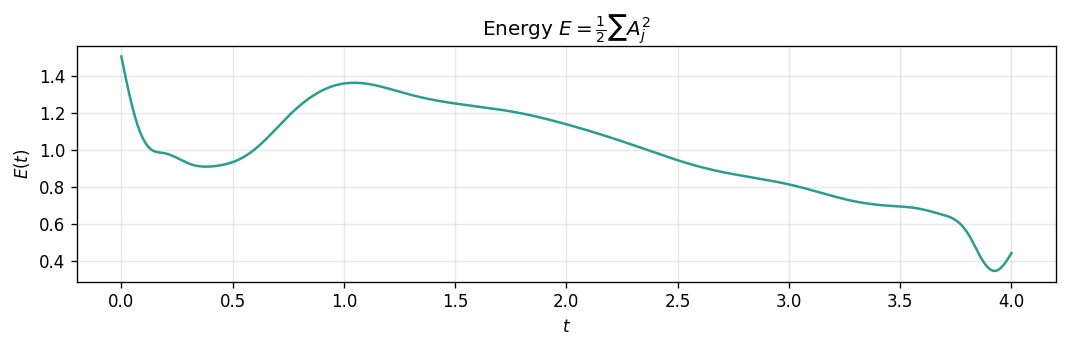

In [5]:
# DI instantaneous frequency / amplitude (paper §6)
amps, freqs = decomp.amplitudes_, decomp.frequencies_
n_osc = amps.shape[0]

fig, axes = plt.subplots(n_osc, 1, figsize=(10, 2.2 * n_osc), sharex=True)
if n_osc == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(t, freqs[i], color="#1f4e79")
    ax.set_ylabel(f"$F_{i+1}$")
axes[-1].set_xlabel("$t$")
fig.suptitle("DI instantaneous frequencies", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2 * n_osc, 1, figsize=(10, 1.8 * 2 * n_osc), sharex=True)
for i in range(n_osc):
    axes[2 * i].plot(t, freqs[i], color="#1f4e79")
    axes[2 * i].set_ylabel(f"$F_{i+1}$")
    axes[2 * i + 1].plot(t, amps[i], color="#c45c26")
    axes[2 * i + 1].set_ylabel(f"$A_{i+1}$")
axes[-1].set_xlabel("$t$")
fig.suptitle("DI frequency & amplitude", y=1.01)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, decomp.energy_, color="#2a9d8f")
ax.set_xlabel("$t$")
ax.set_ylabel("$E(t)$")
ax.set_title(r"Energy $E=\frac{1}{2}\sum A_j^2$")
plt.tight_layout()
plt.show()

## 4. Paper Example 1 — damped sinusoid

A simple AM-like oscillation used in the paper to illustrate sifting / DI:

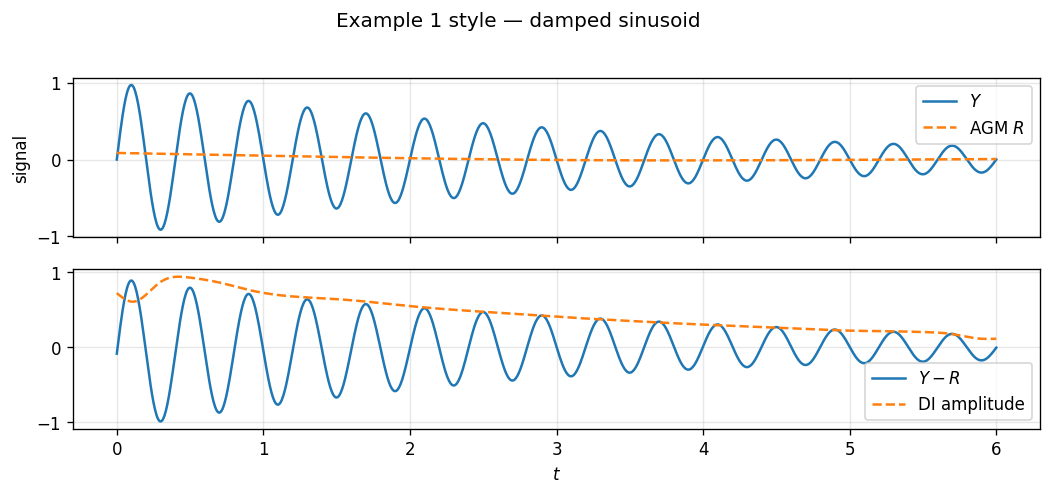

In [6]:
t1 = np.linspace(0.0, 6.0, 1200)
dt1 = float(t1[1] - t1[0])
# damped carrier similar in spirit to Example 1
y1 = np.exp(-0.3 * t1) * np.sin(2.0 * np.pi * 2.5 * t1)

esmd1 = ESMD(n_curves=2, max_sift=20, optimize_sift=False, extreme_num_r=2)
imfs1 = esmd1.fit_transform(y1, dt=dt1, compute_di=True)

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
axes[0].plot(t1, y1, label="$Y$")
axes[0].plot(t1, imfs1[-1], "--", label="AGM $R$")
axes[0].legend()
axes[0].set_ylabel("signal")
axes[1].plot(t1, y1 - imfs1[-1], label="$Y-R$")
if esmd1.amplitudes_.size:
    axes[1].plot(t1, esmd1.amplitudes_[0], "--", label="DI amplitude")
axes[1].legend()
axes[1].set_xlabel("$t$")
fig.suptitle("Example 1 style — damped sinusoid", y=1.02)
plt.tight_layout()
plt.show()

## 5. Multi-scale wind-like series

A synthetic non-stationary series (sample period $\Delta t=0.05$ s) with slow trend, intermediate gusts, and fast fluctuations — the same ESMD workflow as in the paper's wind example: scan $K\in[1,40]$, `extreme_num_r=4`, then plot IMFs, DI $F/A$, AGM overlay, $Y-R$, and energy.

samples = 600, dt = 0.05 s, duration = 29.95 s
opt K0 = 2
min variance ratio = 0.756931
n modes (incl. R) = 4


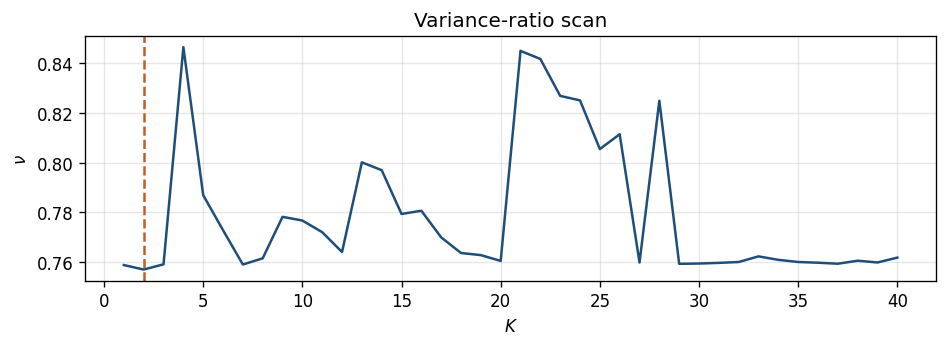

In [7]:
rng = np.random.default_rng(0)
dtw = 0.05
tw = np.arange(0.0, 30.0, dtw)
yw = (
    0.8 * np.sin(2 * np.pi * 0.05 * tw)
    + 1.2 * np.exp(-0.05 * tw) * np.sin(2 * np.pi * 0.35 * tw)
    + 0.6 * np.sin(2 * np.pi * 1.2 * tw + 0.3)
    + 0.15 * rng.normal(size=tw.size)
)
print(f"samples = {yw.size}, dt = {dtw} s, duration = {tw[-1]:.2f} s")

wind_esmd = ESMD(
    n_curves=2,
    min_sift=1,
    max_sift=40,
    extreme_num_r=4,
    optimize_sift=True,
    max_imfs=12,
)
w_imfs = wind_esmd.fit_transform(yw, dt=dtw, compute_di=True)

print(f"opt K0 = {wind_esmd.opt_sift_}")
print(f"min variance ratio = {np.min(wind_esmd.variance_ratios_):.6f}")
print(f"n modes (incl. R) = {w_imfs.shape[0]}")

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(wind_esmd.sift_grid_, wind_esmd.variance_ratios_, color="#1f4e79")
ax.axvline(wind_esmd.opt_sift_, color="#c45c26", ls="--")
ax.set_xlabel("$K$")
ax.set_ylabel(r"$\nu$")
ax.set_title("Variance-ratio scan")
plt.tight_layout()
plt.show()

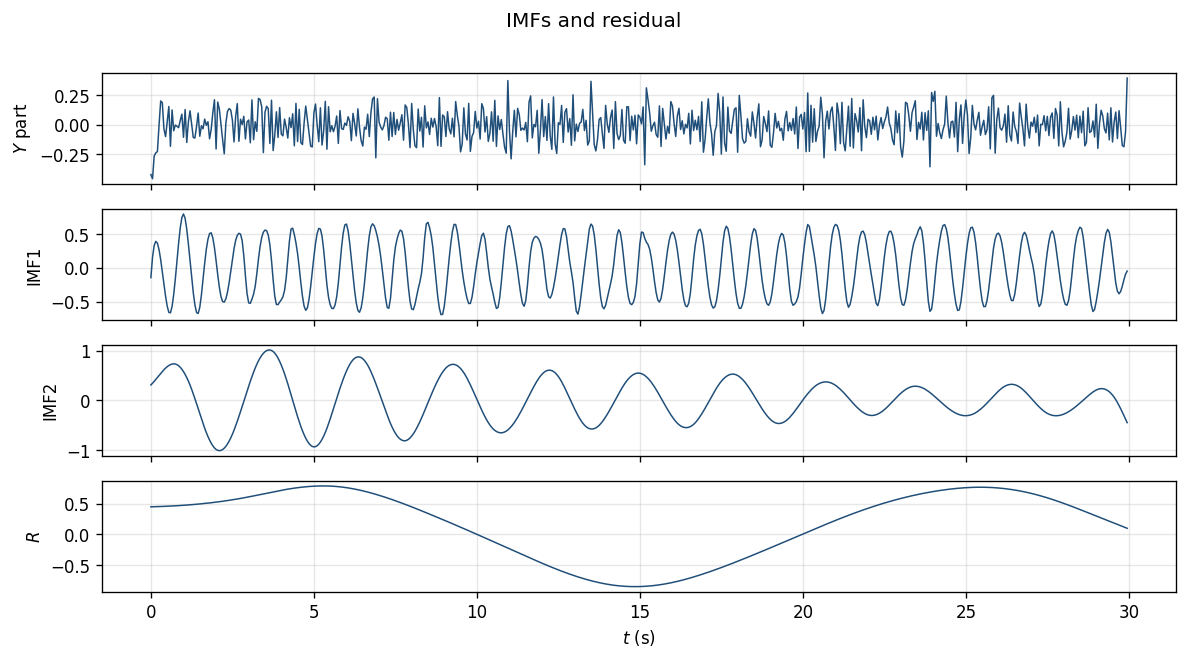

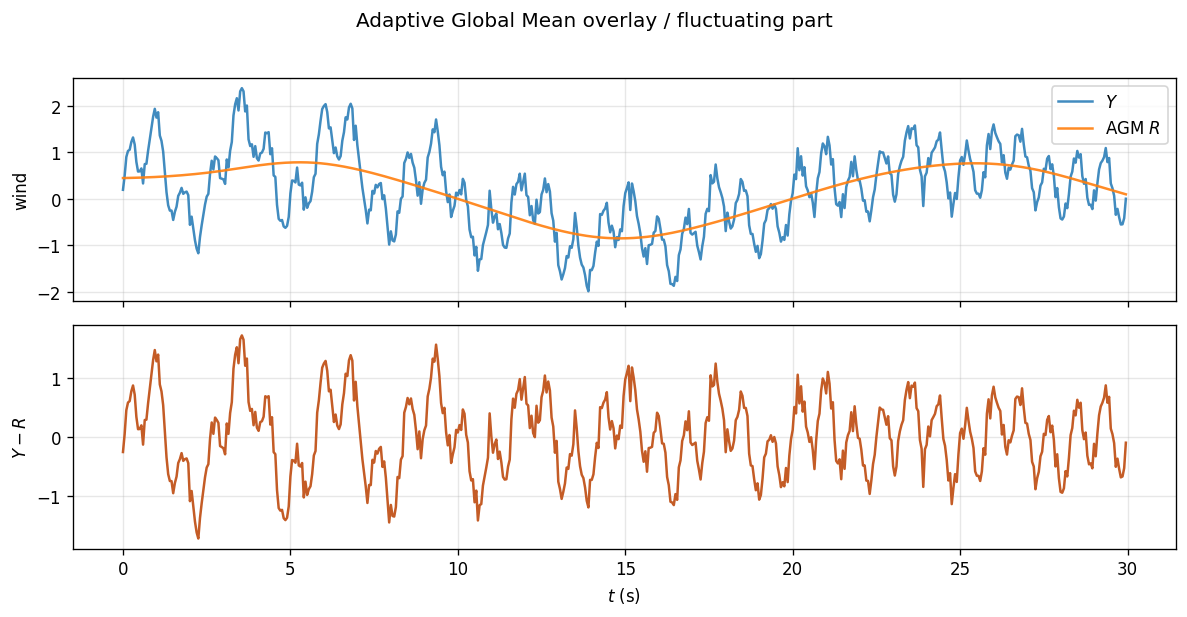

In [8]:
# IMFs + residual
n_rows = w_imfs.shape[0]
fig, axes = plt.subplots(n_rows, 1, figsize=(10, 1.35 * n_rows), sharex=True)
if n_rows == 1:
    axes = [axes]
for i, ax in enumerate(axes):
    ax.plot(tw, w_imfs[i], lw=0.9, color="#1f4e79")
    if i == 0:
        ax.set_ylabel("$Y$ part")
    elif i == n_rows - 1:
        ax.set_ylabel("$R$")
    else:
        ax.set_ylabel(f"IMF{i}")
axes[-1].set_xlabel("$t$ (s)")
fig.suptitle("IMFs and residual", y=1.01)
plt.tight_layout()
plt.show()

# AGM on Y  and  Y-R
R = w_imfs[-1]
fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
axes[0].plot(tw, yw, label="$Y$", alpha=0.85)
axes[0].plot(tw, R, label="AGM $R$", alpha=0.9)
axes[0].legend()
axes[0].set_ylabel("wind")
axes[1].plot(tw, yw - R, color="#c45c26")
axes[1].set_ylabel("$Y-R$")
axes[1].set_xlabel("$t$ (s)")
fig.suptitle("Adaptive Global Mean overlay / fluctuating part", y=1.02)
plt.tight_layout()
plt.show()

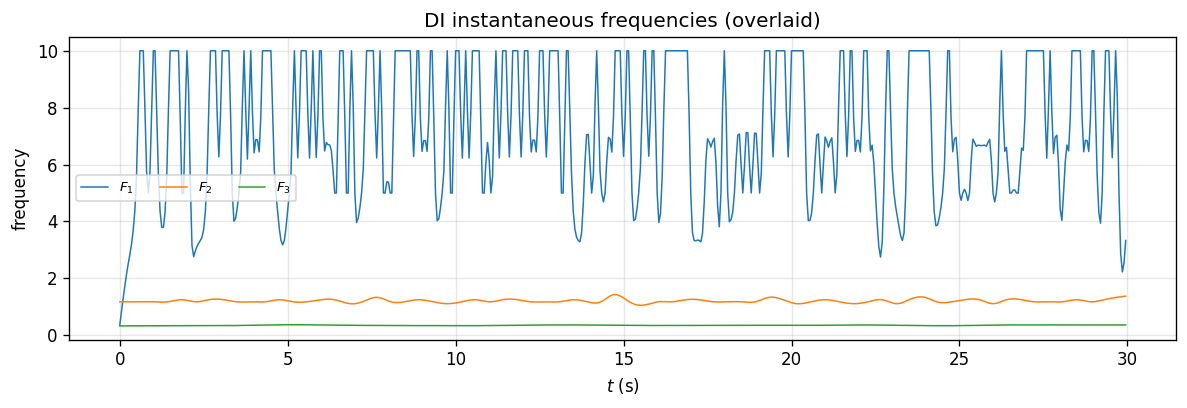

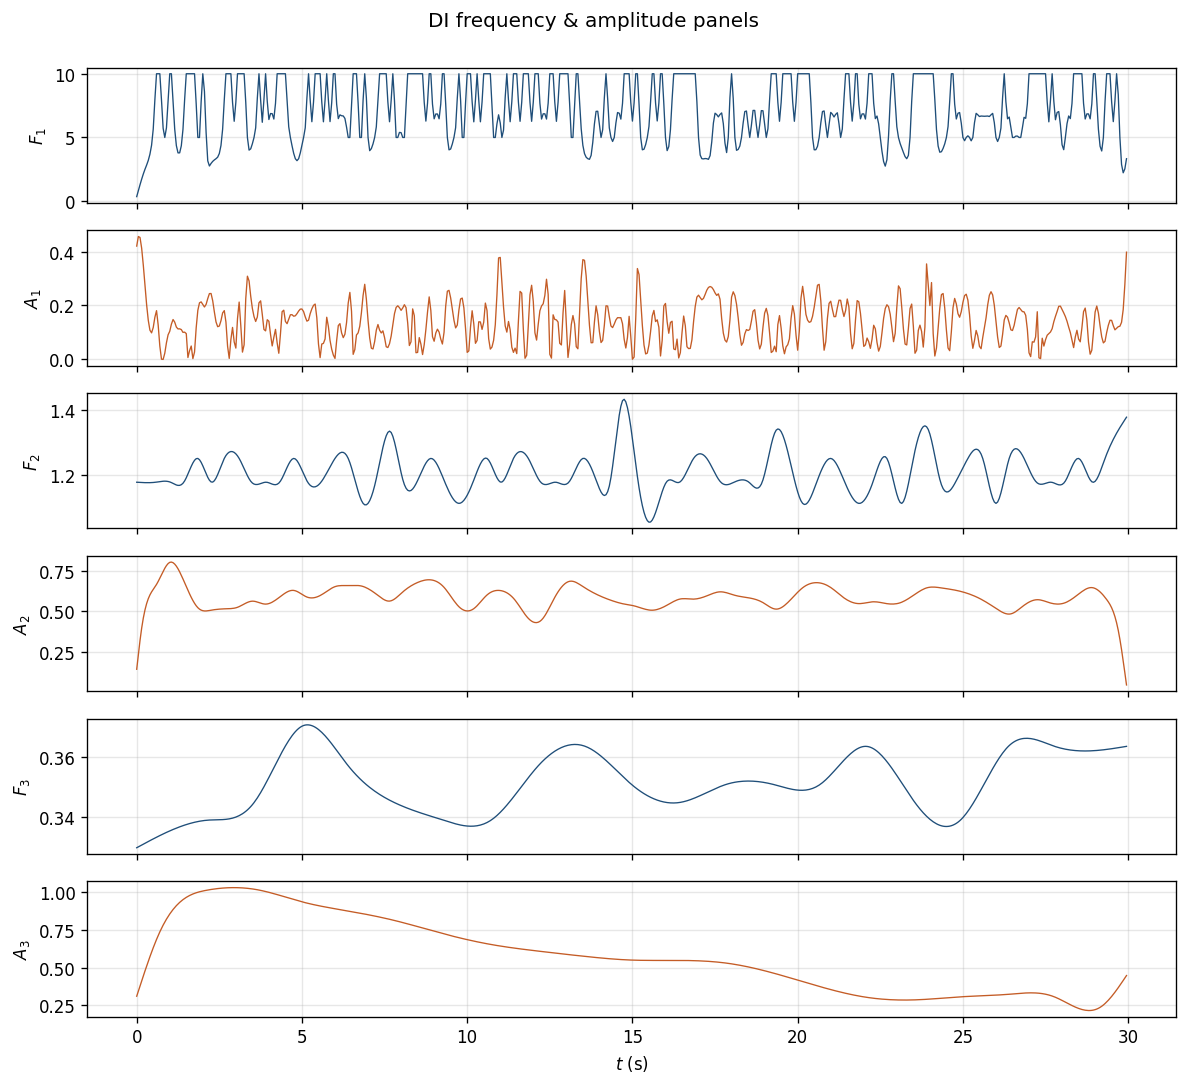

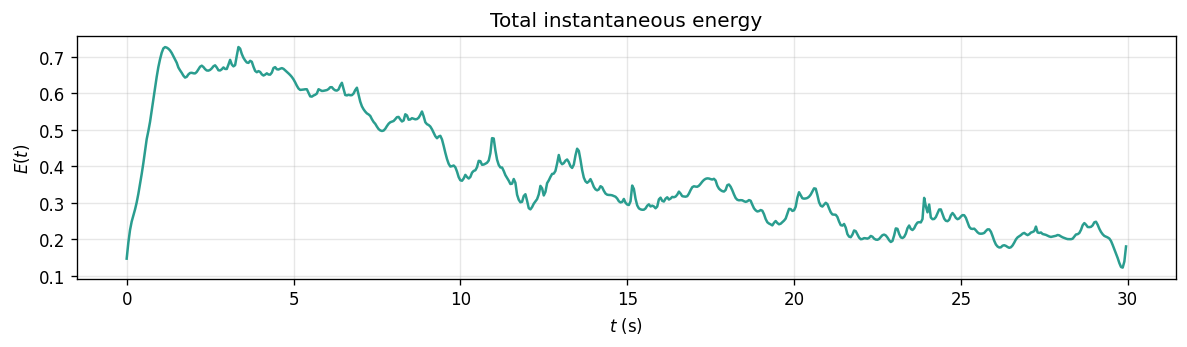

In [9]:
# DI frequencies, F/A panels, energy
w_amps, w_freqs = wind_esmd.amplitudes_, wind_esmd.frequencies_
n_osc = w_amps.shape[0]

fig, ax = plt.subplots(figsize=(10, 3.5))
for i in range(n_osc):
    ax.plot(tw, w_freqs[i], lw=0.9, label=f"$F_{i+1}$")
ax.legend(ncol=min(n_osc, 4), fontsize=8)
ax.set_xlabel("$t$ (s)")
ax.set_ylabel("frequency")
ax.set_title("DI instantaneous frequencies (overlaid)")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2 * n_osc, 1, figsize=(10, 1.5 * 2 * n_osc), sharex=True)
for i in range(n_osc):
    axes[2 * i].plot(tw, w_freqs[i], color="#1f4e79", lw=0.8)
    axes[2 * i].set_ylabel(f"$F_{i+1}$")
    axes[2 * i + 1].plot(tw, w_amps[i], color="#c45c26", lw=0.8)
    axes[2 * i + 1].set_ylabel(f"$A_{i+1}$")
axes[-1].set_xlabel("$t$ (s)")
fig.suptitle("DI frequency & amplitude panels", y=1.0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(tw, wind_esmd.energy_, color="#2a9d8f")
ax.set_xlabel("$t$ (s)")
ax.set_ylabel("$E(t)$")
ax.set_title("Total instantaneous energy")
plt.tight_layout()
plt.show()

## 6. Functional API quick check

Same result via the functional wrapper `esmd(...)`:

In [10]:
imfs_fn = esmd(
    demo["signal"],
    dt=float(demo["dt"]),
    n_curves=2,
    min_sift=5,
    max_sift=20,
    optimize_sift=True,
)
print("functional API shape:", imfs_fn.shape)
print("recon err:", np.max(np.abs(demo["signal"] - imfs_fn.sum(0))))

functional API shape: (3, 800)
recon err: 8.881784197001252e-16


## References

1. J. L. Wang, Z. J. Li. *Extreme-point symmetric mode decomposition method for data analysis.* Advances in Adaptive Data Analysis, 5(3):1350015, 2013. ([arXiv:1303.6540](https://arxiv.org/abs/1303.6540))